# Schelling Toy Model — Paper Reproduction

**Reference:** Sert, Bar-Yam & Morales (2020). *Segregation dynamics with reinforcement learning and agent-based modeling.* Scientific Reports. [doi:10.1038/s41598-020-68447-8](https://doi.org/10.1038/s41598-020-68447-8)

This notebook is a **faithful reproduction** of the `schelling_example.py` toy model from the authors' codebase, using their original `mind.py`, `agent.py`, and `environment.py` files unchanged.

---

### What this notebook reproduces

The authors' Schelling model is an RL-based segregation simulation where:

| Element | Paper implementation |
|---|---|
| **Grid** | 50 × 50, toroidal (periodic BC) |
| **Agent types** | A (value `−1`) and B (value `+1`) |
| **Density** | `p_hunter = 0.05` per type → ~10% occupied |
| **Mind** | Shared CNN-DQN per type (A_mind / B_mind), weight-initialised identically |
| **Observation** | `(2·range+1)²` FOV patch, ego-centric (signed by own type) |
| **Actions** | 5 — up, left, down, right, stay |
| **Reward** | `default(a) = sames + α·diffs` where `sames/diffs` are signed neighborhood deltas |
| **Alive bonus** | `β · 0.1` added to every non-penalty reward |
| **Interdependence** | `γ · prey_reward` added when killing a prey agent |
| **Lifespan** | Agents die at `max_age` steps; resurrect with probability `p_resurrection=0.2` |
| **Convergence** | Stop early if `|map_t − map_{t−1}|₁ < ε` for 20 consecutive steps |

### Parameters from the paper's shell command
```
python schelling_example.py <name> <iterations> <agent_range> <prey_reward> <max_age> <alpha> <beta> <gamma>
```
Default experiment (Section 3): `agent_range=5, prey_reward=75, max_age=100, α=β=γ=1`

## 0. Imports & reproducibility

In [1]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import os, sys, random, time, shutil
import numpy as np
import torch
from multiprocessing import Lock

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.animation as animation
from matplotlib.patches import Patch
from IPython.display import HTML
from scipy.ndimage import label as scipy_label

# ── The authors' original classes (unchanged) ────────────────────────────────
from environment import Environment
from schelling_example import Schelling, play

# ── Seeds (matching the paper's __main__ block) ──────────────────────────────
SEED = 1
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

matplotlib.rcParams['figure.dpi'] = 120
print('All imports OK.')
print(f'PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')

All imports OK.
PyTorch 2.7.0 | CUDA: False


## 1. Visual helpers

The original code stores the grid as float values `{−1, 0, 1, 2}` (A, free, B, prey).
We map these to a discrete colormap for display.

In [9]:
# ── Colormap matching the paper's convention ─────────────────────────────────
#   -1 → type A   (blue)
#    0 → empty    (off-white)
#    1 → type B   (red)
#    2 → prey     (gold)

_CMAP  = mcolors.ListedColormap(['#4a90d9', '#f5f5f5', '#e05252', '#f5a623'])
_BOUNDS = [-1.5, -0.5, 0.5, 1.5, 2.5]
_NORM  = mcolors.BoundaryNorm(_BOUNDS, _CMAP.N)
_LEGEND = [
    Patch(facecolor='#4a90d9', edgecolor='#aaa', label='Empty'),
    Patch(facecolor='#f5f5f5', label='Type A (−1)'),
    Patch(facecolor='#e05252', label='Type B (+1)'),
    Patch(facecolor='#f5a623', label='Prey (2)'),
]

def show_grid(grid, title='', ax=None):
    """Render one map snapshot."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(grid, cmap=_CMAP, norm=_NORM, interpolation='nearest')
    ax.set_title(title, fontsize=12, pad=6)
    ax.axis('off')
    ax.legend(handles=_LEGEND, loc='lower right', fontsize=7, framealpha=0.9)
    if standalone:
        plt.tight_layout()
        plt.show()

def show_snapshots(grids_dict, suptitle=''):
    """Row of snapshots at given timesteps."""
    steps = sorted(grids_dict)
    fig, axes = plt.subplots(1, len(steps), figsize=(4 * len(steps), 4))
    if len(steps) == 1:
        axes = [axes]
    for ax, t in zip(axes, steps):
        show_grid(grids_dict[t], title=f't = {t}', ax=ax)
    if suptitle:
        plt.suptitle(suptitle, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

print('Helpers defined.')

Helpers defined.


## 2. Metric functions

These reproduce the quantities discussed in the paper:

- **Segregation index** $S$: mean fraction of same-type neighbors across all agents.
- **Cluster size distribution**: connected components of each type (scipy).
- **Agent survival** (age tracking via the crystal tensor).

In [3]:
# ── Paper grid convention: A=-1, free=0, B=+1, prey=2 ────────────────────────

def segregation_index(grid, agent_type, radius=1):
    """
    Fraction of non-empty, non-prey neighbors that share `agent_type`,
    averaged over all agents of that type.
    Toroidal boundary conditions.
    """
    N, M = grid.shape
    scores = []
    for r in range(N):
        for c in range(M):
            if grid[r, c] != agent_type:
                continue
            same = total = 0
            for dr in range(-radius, radius + 1):
                for dc in range(-radius, radius + 1):
                    if dr == 0 and dc == 0:
                        continue
                    val = grid[(r + dr) % N, (c + dc) % M]
                    if val in (-1, 1):          # only count A and B
                        total += 1
                        if val == agent_type:
                            same += 1
            if total > 0:
                scores.append(same / total)
    return float(np.mean(scores)) if scores else 0.0

def global_segregation(grid, radius=1):
    """Mean of type-A and type-B segregation indices."""
    sa = segregation_index(grid, -1, radius)
    sb = segregation_index(grid,  1, radius)
    return (sa + sb) / 2

def cluster_sizes(grid, agent_type):
    """Sorted list of connected-component sizes for one agent type."""
    mask = (grid == agent_type).astype(int)
    labeled, n = scipy_label(mask)
    sizes = [int(np.sum(labeled == k)) for k in range(1, n + 1)]
    return sorted(sizes, reverse=True)

def count_agents(grid):
    """Return dict with counts of A, B, prey, empty."""
    return {
        'A':     int(np.sum(grid == -1)),
        'B':     int(np.sum(grid ==  1)),
        'prey':  int(np.sum(grid ==  2)),
        'empty': int(np.sum(grid ==  0)),
    }

print('Metrics defined.')

Metrics defined.


## 3. Experiment 1 — Default paper parameters

Equivalent to running:
```
python schelling_example.py  my_exp  50  5  75  100  1  1  1
```

We wrap `play()` to intercept the map at each iteration so we can compute metrics and save snapshots — without modifying any original file.

In [4]:
# ── Parameters (paper defaults) ───────────────────────────────────────────────
GRID_SIZE    = (20, 20)
P_HUNTER     = 0.05      # density per type  (~10% total occupied)
P_PREY       = 0.0       # pure Schelling: no prey
AGENT_RANGE  = 5         # FOV radius  → 11×11 patch, 121-dim CNN input
PREY_REWARD  = 75        # gamma reward multiplier (unused when p_prey=0)
MAX_AGE      = 100       # steps before natural death
ALPHA        = 1.0       # weight of opposite-type neighbor penalty
BETA         = 1.0       # weight of alive bonus
GAMMA        = 1.0       # weight of predation reward
ITERATIONS   = 50       # max steps
EPS_CONV     = 1e-6      # convergence threshold (paper default)
SNAP_STEPS   = [0, 10, 20, 30, 40, 49]  # steps to snapshot

EXP_NAME = 'paper_default'

# Clean up any leftover experiment directory
if os.path.isdir(EXP_NAME):
    shutil.rmtree(EXP_NAME)

print('Parameters set.')
print(f'  Grid          : {GRID_SIZE[0]}×{GRID_SIZE[1]}')
print(f'  Agent range   : {AGENT_RANGE}  (FOV = {2*AGENT_RANGE+1}×{2*AGENT_RANGE+1} = {(2*AGENT_RANGE+1)**2} dims)')
print(f'  α={ALPHA}  β={BETA}  γ={GAMMA}')
print(f'  Max iterations: {ITERATIONS}')

Parameters set.
  Grid          : 20×20
  Agent range   : 5  (FOV = 11×11 = 121 dims)
  α=1.0  β=1.0  γ=1.0
  Max iterations: 50


Environment created.
  A agents : 25
  B agents : 19
  Prey     : 0
  Empty    : 356
  Initial segregation (radius=1): 0.662


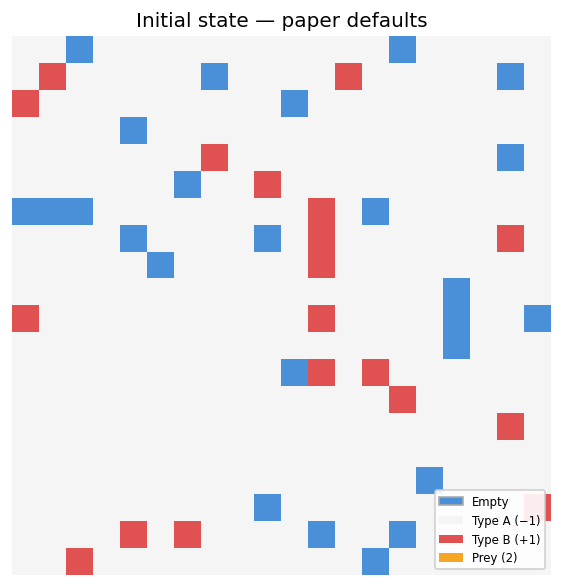

In [10]:
# ── Build the Schelling environment ───────────────────────────────────────────
np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)

society = Schelling(
    GRID_SIZE,
    p_hunter      = P_HUNTER,
    p_prey        = P_PREY,
    prey_reward   = PREY_REWARD,
    agent_max_age = MAX_AGE,
    agent_range   = AGENT_RANGE,
    max_iteration = ITERATIONS,
    lock          = Lock(),
    name          = EXP_NAME,
    alpha         = ALPHA,
    beta          = BETA,
    gamma         = GAMMA,
)

initial_grid = society.get_map().copy()
counts = count_agents(initial_grid)

print('Environment created.')
print(f'  A agents : {counts["A"]}')
print(f'  B agents : {counts["B"]}')
print(f'  Prey     : {counts["prey"]}')
print(f'  Empty    : {counts["empty"]}')
print(f'  Initial segregation (radius=1): {global_segregation(initial_grid):.3f}')

show_grid(initial_grid, title='Initial state — paper defaults')

In [11]:
# ── Instrumented play loop ────────────────────────────────────────────────────
#
# We replicate play() from schelling_example.py exactly, adding:
#   - metric recording at each step
#   - snapshot saving at SNAP_STEPS
#   - early-stop detection (same logic as the original)
#
# This touches NO original source files.

def run_instrumented(society, iterations, snap_steps=None, eps=1e-6, verbose=True):
    """
    Instrumented version of the authors' play() loop.

    Returns
    -------
    metrics   : dict with per-step lists of seg_A, seg_B, seg_global,
                reward_A, reward_B, n_A, n_B
    snapshots : dict {step: grid_array}
    """
    from itertools import count as icount

    agents     = society.get_agents()
    directions = [(-1, 0), (0, -1), (1, 0), (0, 1), (0, 0)]  # paper order

    if snap_steps is None:
        snap_steps = set()
    else:
        snap_steps = set(snap_steps)

    metrics = {
        'seg_A': [], 'seg_B': [], 'seg_global': [],
        'reward_A': [], 'reward_B': [],
        'n_A': [], 'n_B': [],
        'converged_at': None,
    }
    snapshots = {}
    c = 0          # consecutive convergence counter
    times = 0

    state = society.get_map()

    for t in icount():
        t_start = time.time()
        random.shuffle(agents)

        rews   = {'A': 0.0, 'B': 0.0, 'prey': 0.0}
        counts_ = {'A': 0,   'B': 0,   'prey': 0}

        for agent in agents:
            towards = None
            name = society.vals_to_names[agent.get_type()]
            if agent.is_alive():
                agent_state = agent.get_state()
                action      = agent.decide(agent_state)   # original Agent.decide()
                towards     = directions[action]
            rew = society.step(agent, towards)            # original Environment.step()
            rews[name]    += rew
            counts_[name] += 1

        society.update()                                  # trains A_mind / B_mind
        society.record(rews)

        next_state = society.get_map()

        # ── Record metrics ───────────────────────────────────────────────────
        c_A  = counts_['A'] or 1
        c_B  = counts_['B'] or 1
        sg   = global_segregation(next_state, radius=1)
        sa   = segregation_index(next_state, -1, radius=1)
        sb   = segregation_index(next_state,  1, radius=1)
        cnt  = count_agents(next_state)

        metrics['seg_A'].append(sa)
        metrics['seg_B'].append(sb)
        metrics['seg_global'].append(sg)
        metrics['reward_A'].append(rews['A'] / c_A)
        metrics['reward_B'].append(rews['B'] / c_B)
        metrics['n_A'].append(cnt['A'])
        metrics['n_B'].append(cnt['B'])

        if t in snap_steps:
            snapshots[t] = next_state.copy()

        # ── Convergence check (paper's original logic) ───────────────────────
        if np.abs(next_state - state).sum() < eps:
            c += 1
        else:
            c = 0

        # ── Progress ─────────────────────────────────────────────────────────
        times += time.time() - t_start
        if verbose and (t % 50 == 0 or t == iterations - 1):
            print(f'  step {t:4d}/{iterations} | '
                  f'Seg={sg:.3f} (A={sa:.3f} B={sb:.3f}) | '
                  f'R_A={rews["A"]/c_A:+.3f}  R_B={rews["B"]/c_B:+.3f} | '
                  f'N_A={cnt["A"]} N_B={cnt["B"]} | '
                  f'avg_t={times/(t+1):.2f}s')

        if t == iterations - 1 or c == 20:
            if c == 20:
                metrics['converged_at'] = t
                print(f'\n  *** Converged at step {t} (20 consecutive unchanged maps) ***')
            break

        state = next_state

    society.save(0)   # write crystal.npy.gz  (original save method)
    print('\nSimulation finished.')
    return metrics, snapshots


print('Instrumented loop defined.')

Instrumented loop defined.


In [12]:
print(f'Running "{EXP_NAME}" for up to {ITERATIONS} steps...\n')
metrics, snapshots = run_instrumented(
    society,
    iterations = ITERATIONS,
    snap_steps = SNAP_STEPS,
    eps        = EPS_CONV,
    verbose    = True,
)

Running "paper_default" for up to 50 steps...

  step    0/50 | Seg=0.682 (A=0.636 B=0.727) | R_A=-0.248  R_B=-0.258 | N_A=25 N_B=19 | avg_t=0.01s


/home/paul-guimbard/Bureau/ICFP/S2/ML/projet /segregation/mind.py:142: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /home/task_177081057165514/croot/libtorch_1770810630944/work/torch/csrc/utils/tensor_new.cpp:254.)
  batch_state = torch.cat([torch.FloatTensor(s) for s in batch_state])


  step   49/50 | Seg=0.476 (A=0.536 B=0.417) | R_A=-0.008  R_B=-0.468 | N_A=24 N_B=17 | avg_t=2.11s

Simulation finished.


## 4. Grid evolution snapshots

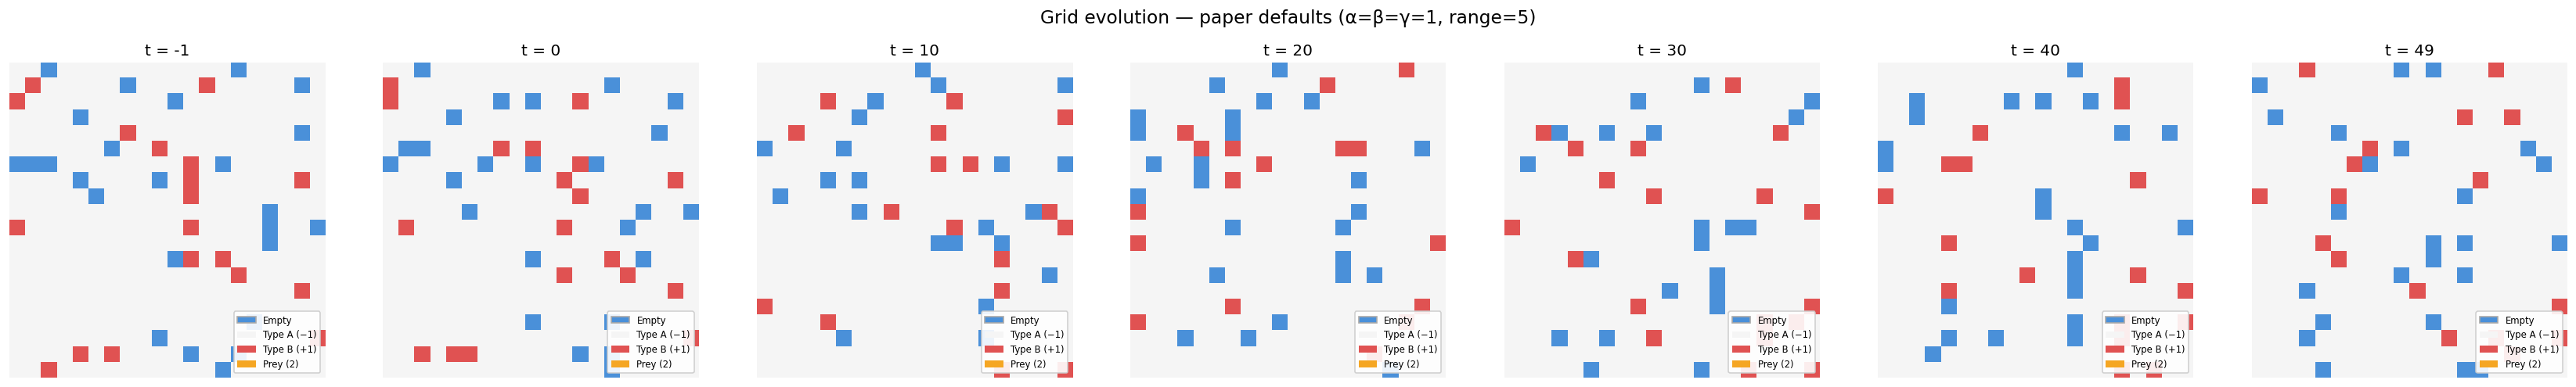

In [13]:
# Add the initial state at t=0 if we captured it
all_snaps = {-1: initial_grid, **snapshots}
show_snapshots(all_snaps, suptitle='Grid evolution — paper defaults (α=β=γ=1, range=5)')

## 5. Segregation dynamics over time

The key Figure 2 / Figure 3 of the paper: how the **segregation index** $S$ evolves as agents learn to cluster with their own type.

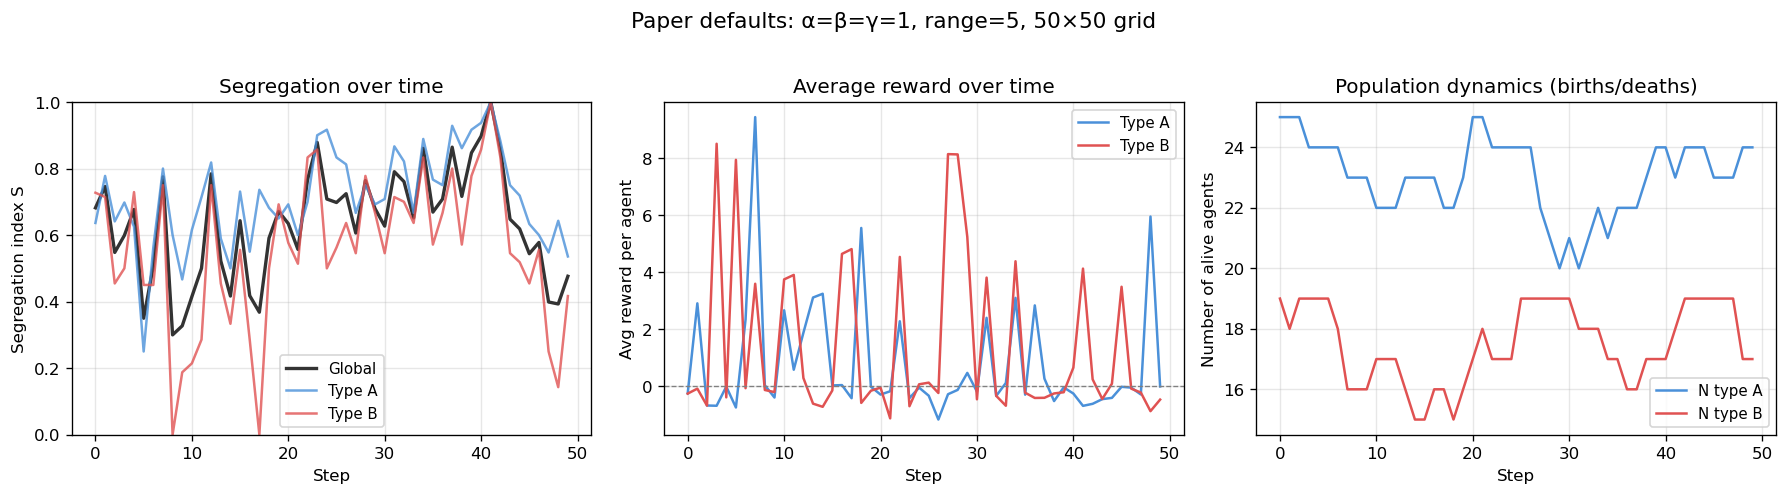

In [14]:
steps = np.arange(len(metrics['seg_global']))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Segregation index ─────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(steps, metrics['seg_global'], color='#333',   lw=2,   label='Global')
ax.plot(steps, metrics['seg_A'],      color='#4a90d9', lw=1.5, label='Type A', alpha=0.8)
ax.plot(steps, metrics['seg_B'],      color='#e05252', lw=1.5, label='Type B', alpha=0.8)
if metrics['converged_at']:
    ax.axvline(metrics['converged_at'], ls='--', color='green', lw=1, label='Convergence')
ax.set_xlabel('Step');  ax.set_ylabel('Segregation index S')
ax.set_title('Segregation over time')
ax.set_ylim(0, 1);  ax.legend(fontsize=9);  ax.grid(alpha=0.3)

# ── Average reward ───────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(steps, metrics['reward_A'], color='#4a90d9', lw=1.5, label='Type A')
ax.plot(steps, metrics['reward_B'], color='#e05252', lw=1.5, label='Type B')
ax.axhline(0, ls='--', color='gray', lw=0.8)
ax.set_xlabel('Step');  ax.set_ylabel('Avg reward per agent')
ax.set_title('Average reward over time')
ax.legend(fontsize=9);  ax.grid(alpha=0.3)

# ── Population dynamics ───────────────────────────────────────────────────────
ax = axes[2]
ax.plot(steps, metrics['n_A'], color='#4a90d9', lw=1.5, label='N type A')
ax.plot(steps, metrics['n_B'], color='#e05252', lw=1.5, label='N type B')
ax.set_xlabel('Step');  ax.set_ylabel('Number of alive agents')
ax.set_title('Population dynamics (births/deaths)')
ax.legend(fontsize=9);  ax.grid(alpha=0.3)

plt.suptitle('Paper defaults: α=β=γ=1, range=5, 50×50 grid', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Cluster size distribution (final state)

The spatial structure of segregation: large clusters = strong spatial separation.

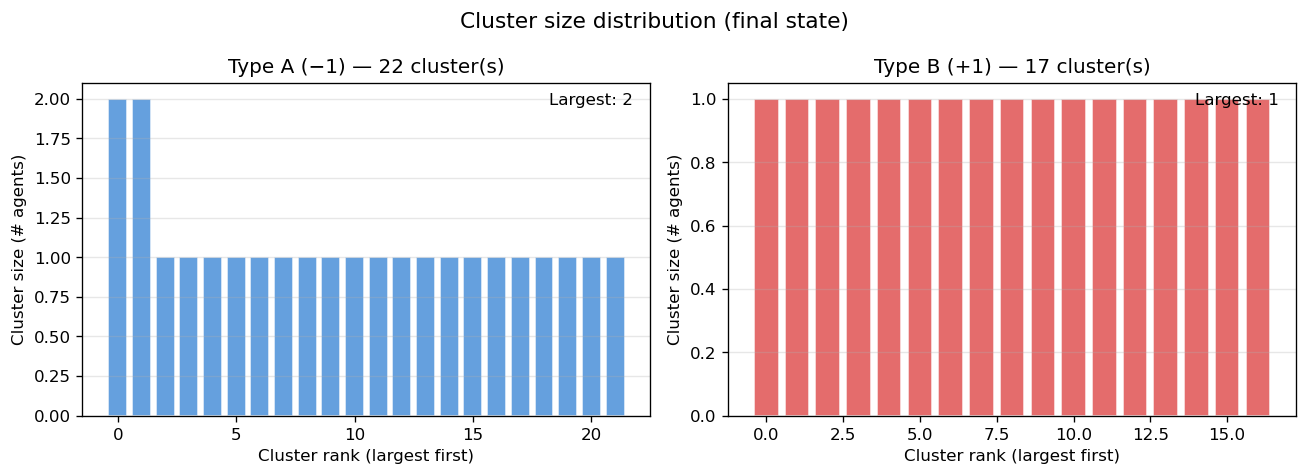

Final global segregation index : 0.4762
Type A: 22 clusters, largest = 2
Type B: 17 clusters, largest = 1


In [15]:
final_grid = society.get_map()

sizes_A = cluster_sizes(final_grid, agent_type=-1)
sizes_B = cluster_sizes(final_grid, agent_type= 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, sizes, label, color in [
    (axes[0], sizes_A, 'A (−1)', '#4a90d9'),
    (axes[1], sizes_B, 'B (+1)', '#e05252'),
]:
    if sizes:
        ax.bar(range(len(sizes)), sizes, color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel('Cluster rank (largest first)')
    ax.set_ylabel('Cluster size (# agents)')
    ax.set_title(f'Type {label} — {len(sizes)} cluster(s)')
    ax.grid(axis='y', alpha=0.3)
    if sizes:
        ax.text(0.97, 0.97, f'Largest: {sizes[0]}',
                ha='right', va='top', transform=ax.transAxes, fontsize=10)

plt.suptitle('Cluster size distribution (final state)', fontsize=13)
plt.tight_layout()
plt.show()

# Summary
seg_final = global_segregation(final_grid)
print(f'Final global segregation index : {seg_final:.4f}')
print(f'Type A: {len(sizes_A)} clusters, largest = {sizes_A[0] if sizes_A else 0}')
print(f'Type B: {len(sizes_B)} clusters, largest = {sizes_B[0] if sizes_B else 0}')

## 7. Parameter sweep — effect of α (segregation affinity)

In the paper, **α** controls how much agents are penalised for having opposite-type neighbors.

| α | Interpretation |
|---|---|
| 0 | Agents only care about gaining same-type neighbors — pure integration preference |
| 1 | Standard Schelling: equal weight on gains and losses (paper default) |
| >1 | Hyper-segregationist: opposite-type neighbors are penalised more than same-type gains are rewarded |

The reward formula from `schelling_example.py`:
```python
def default(self, agent):
    default = agent.get_type() * (curr - prev)   # signed neighborhood delta
    sames = default[default >  0.1].sum()         # gained same-type neighbors
    diffs = default[default < -0.1].sum()         # gained opposite-type neighbors
    return sames + alpha * diffs                   # diffs is negative
```

In [ ]:
# ── Sweep over alpha values ───────────────────────────────────────────────────
ALPHA_VALUES  = [0.0, 0.5, 1.0, 2.0]
SWEEP_ITERS   = 200          # shorter for speed
SWEEP_RANGE   = 2            # smaller FOV to keep it fast

alpha_results = {}   # alpha -> metrics dict

for alpha_val in ALPHA_VALUES:
    exp_name = f'sweep_alpha_{alpha_val}'
    if os.path.isdir(exp_name):
        shutil.rmtree(exp_name)

    np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)

    env = Schelling(
        GRID_SIZE,
        p_hunter      = P_HUNTER,
        p_prey        = 0.0,
        prey_reward   = PREY_REWARD,
        agent_max_age = MAX_AGE,
        agent_range   = SWEEP_RANGE,
        max_iteration = SWEEP_ITERS,
        lock          = Lock(),
        name          = exp_name,
        alpha         = alpha_val,
        beta          = BETA,
        gamma         = GAMMA,
    )

    print(f'\nRunning α={alpha_val} ...')
    m, _ = run_instrumented(env, SWEEP_ITERS, snap_steps=[], verbose=False)
    alpha_results[alpha_val] = m
    print(f'  Final seg = {m["seg_global"][-1]:.3f}')

print('\nSweep complete.')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_sweep = ['#9b59b6', '#3498db', '#2ecc71', '#e74c3c']

for (alpha_val, m), col in zip(alpha_results.items(), colors_sweep):
    steps_s = np.arange(len(m['seg_global']))
    axes[0].plot(steps_s, m['seg_global'], lw=2, color=col, label=f'α = {alpha_val}')
    axes[1].plot(steps_s, m['reward_A'],   lw=2, color=col, label=f'α = {alpha_val}')

axes[0].set_xlabel('Step'); axes[0].set_ylabel('Segregation index S')
axes[0].set_title('Segregation dynamics vs α'); axes[0].set_ylim(0, 1)
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Step'); axes[1].set_ylabel('Avg reward (type A)')
axes[1].set_title('Avg reward vs α')
axes[1].axhline(0, ls='--', color='gray', lw=0.8)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Effect of α (opposite-type penalty weight)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Parameter sweep — effect of agent_range (field of view)

`agent_range` controls the radius of each agent's observation patch:

| range | window | CNN input |
|---|---|---|
| 1 | 3×3 | 9 |
| 2 | 5×5 | 25 |
| 3 | 7×7 | 49 |
| 5 | 11×11 | 121 (paper default) |

Larger range → agents can "see" further → potentially faster/stronger segregation.

In [ ]:
RANGE_VALUES = [1, 2, 3]
range_results = {}

for rng in RANGE_VALUES:
    exp_name = f'sweep_range_{rng}'
    if os.path.isdir(exp_name):
        shutil.rmtree(exp_name)

    np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)

    env = Schelling(
        GRID_SIZE,
        p_hunter      = P_HUNTER,
        p_prey        = 0.0,
        prey_reward   = PREY_REWARD,
        agent_max_age = MAX_AGE,
        agent_range   = rng,
        max_iteration = SWEEP_ITERS,
        lock          = Lock(),
        name          = exp_name,
        alpha         = ALPHA,
        beta          = BETA,
        gamma         = GAMMA,
    )

    print(f'Running range={rng} (FOV {2*rng+1}×{2*rng+1}) ...')
    m, _ = run_instrumented(env, SWEEP_ITERS, snap_steps=[], verbose=False)
    range_results[rng] = m
    print(f'  Final seg = {m["seg_global"][-1]:.3f}')

print('\nSweep complete.')

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
colors_r = ['#e74c3c', '#3498db', '#2ecc71']

for (rng, m), col in zip(range_results.items(), colors_r):
    ax.plot(m['seg_global'], lw=2, color=col,
            label=f'range={rng} ({(2*rng+1)**2}-dim)')

ax.set_xlabel('Step'); ax.set_ylabel('Segregation index S')
ax.set_title('Effect of agent\'s field of view (agent_range)')
ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Crystal tensor analysis

The `crystal.npy.gz` file is the paper's primary output artefact.
It is a `(T, H, W, 4)` tensor: `[agent_type, age, time_remaining, agent_id]` per cell per step.

Here we load it and extract **agent lifespan distributions** — the age at death — which the paper uses to study survival dynamics.

In [ ]:
crystal_path = f'{EXP_NAME}/crystal.npy.gz'

import gzip
with gzip.GzipFile(crystal_path, 'r') as f:
    crystal = np.load(f)

T, H, W, C = crystal.shape
print(f'Crystal shape: {crystal.shape}')
print(f'  Channels: [agent_type, age, time_remaining, agent_id]')
print(f'  Steps recorded: {T}')

# ── Extract age-at-death via agent_id tracking ────────────────────────────────
#
# For each agent_id, find the last step it appears on the map.
# Its age at that step (crystal[t, i, j, 1]) is its age at death.

id_last_age  = {}   # agent_id -> age at last recorded step
id_type_seen = {}   # agent_id -> type

for t in range(T):
    for i in range(H):
        for j in range(W):
            c0 = crystal[t, i, j, 0]   # type
            c1 = crystal[t, i, j, 1]   # age
            c3 = crystal[t, i, j, 3]   # id
            if c3 != 0 or c0 != 0:     # occupied cell
                aid = int(c3)
                id_last_age[aid]  = int(c1)
                id_type_seen[aid] = int(c0)

ages_A = [age for aid, age in id_last_age.items() if id_type_seen.get(aid) == -1]
ages_B = [age for aid, age in id_last_age.items() if id_type_seen.get(aid) ==  1]

print(f'\nTracked {len(ages_A)} type-A agents, {len(ages_B)} type-B agents')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, ages, label, color in [
    (axes[0], ages_A, 'Type A (−1)', '#4a90d9'),
    (axes[1], ages_B, 'Type B (+1)', '#e05252'),
]:
    if ages:
        ax.hist(ages, bins=20, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(np.mean(ages), ls='--', color='black', lw=1.5,
                   label=f'Mean = {np.mean(ages):.1f}')
    ax.set_xlabel('Age at last observation')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} — age distribution')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Agent lifespan distribution (from crystal tensor)', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Animation of the simulation

We replay the `history` list stored by `Environment.update()` as a frame-by-frame animation.

In [ ]:
# history is a list of map copies, one per call to society.update()
history = society.history
print(f'Animation: {len(history)} frames available.')

# Sub-sample to at most 80 frames for a smooth but fast animation
n_frames = min(80, len(history))
indices  = np.linspace(0, len(history) - 1, n_frames, dtype=int)
frames   = [history[i] for i in indices]

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(frames[0], cmap=_CMAP, norm=_NORM, interpolation='nearest')
ax.axis('off')
ax.set_title('Schelling model — paper defaults')
ax.legend(handles=_LEGEND, loc='lower right', fontsize=7, framealpha=0.9)
txt = ax.text(0.02, 0.97, '', transform=ax.transAxes, fontsize=10, va='top', color='black')

def _update(frame_idx):
    im.set_data(frames[frame_idx])
    txt.set_text(f't = {indices[frame_idx]}')
    return [im, txt]

anim = animation.FuncAnimation(fig, _update, frames=n_frames, interval=150, blit=True)
plt.tight_layout()
HTML(anim.to_jshtml())

## 11. Summary table

In [ ]:
final = society.get_map()
cnt   = count_agents(final)
cvg   = metrics['converged_at']

print('=' * 55)
print('  PAPER DEFAULT EXPERIMENT — SUMMARY')
print('=' * 55)
print(f'  Grid              : {GRID_SIZE[0]}×{GRID_SIZE[1]}')
print(f'  Parameters        : α={ALPHA}  β={BETA}  γ={GAMMA}')
print(f'  Agent range       : {AGENT_RANGE}  (FOV {2*AGENT_RANGE+1}×{2*AGENT_RANGE+1})')
print(f'  Steps run         : {len(metrics["seg_global"])}')
print(f'  Converged at      : {cvg if cvg else "not converged"}')
print('-' * 55)
print(f'  Initial seg index : {global_segregation(initial_grid):.4f}')
print(f'  Final seg index   : {metrics["seg_global"][-1]:.4f}')
print(f'  Δ segregation     : {metrics["seg_global"][-1] - metrics["seg_global"][0]:+.4f}')
print('-' * 55)
print(f'  Alive agents A    : {cnt["A"]}')
print(f'  Alive agents B    : {cnt["B"]}')
sz_A = cluster_sizes(final, -1)
sz_B = cluster_sizes(final,  1)
print(f'  Type-A clusters   : {len(sz_A)}  (largest: {sz_A[0] if sz_A else 0})')
print(f'  Type-B clusters   : {len(sz_B)}  (largest: {sz_B[0] if sz_B else 0})')
print('=' * 55)

---

## Notes on the original code

### Grid value encoding
The original code uses `{−1, 0, +1, 2}` (A, free, B, prey) — different from many Schelling implementations that use `{0,1,2}`. The opponent detection in `Environment.step()` exploits this:
```python
elif self.map[i_n, j_n] * agent.get_type() == -1:   # product is -1 iff types differ
    rew = self.on_opponent(agent, opponent)
```

### Shared mind architecture
All type-A agents share one `Mind` (a CNN-DQN), all type-B agents share another. Initialised with the same weights when `same=True` (default). This means **each type learns a single collective policy**, not one policy per agent — a key design choice that reduces computational cost and enforces type symmetry.

### The `default()` reward
```python
def default(self, agent):
    curr = self.get_agent_state(agent)   # new FOV patch
    prev = agent.get_state()             # FOV before the move
    delta = agent.get_type() * (curr - prev)   # ego-centric signed change
    sames = delta[delta >  0.1].sum()   # cells that became same-type
    diffs = delta[delta < -0.1].sum()   # cells that became opposite-type
    return sames + alpha * diffs         # diffs is negative
```
This is a **neighborhood-change reward**, not an absolute satisfaction score. Agents are rewarded for *improvements* in their local composition, not for the composition itself. With α=1 the reward is symmetric; with α>1 avoiding opposite neighbors matters more than gaining same-type ones.

### Citation
```
@article{Sert2020,
  doi     = {10.1038/s41598-020-68447-8},
  year    = {2020},
  volume  = {10},
  author  = {Egemen Sert and Yaneer Bar-Yam and Alfredo J. Morales},
  title   = {Segregation dynamics with reinforcement learning and agent-based modeling},
  journal = {Scientific Reports}
}
```